[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab0-ML/notebooks/01a-Simple_examples_solutions.ipynb)

# 📝 Solutions and discussions: diabetes prediction

This notebook provides reasoned answers to the 15 tasks from the main notebook `01-Simple_examples.ipynb`.

**Contents:**
- Tasks 1–5: Technical solutions with code
- Tasks 6–8: Analytical solutions
- Tasks 9–12: Ethical discussions
- Tasks 13–15: Clinical perspectives

---

**Version:** 2025-12-20

---

## 📝 Tasks and reflections: diabetes prediction

Before moving on to the interactive web app, here are 15 tasks and perspectives you can explore and discuss. They cover both technical and ethical aspects of medical machine learning.

---

## 🔧 Technical tasks (coding)

### Task 1: Improve model performance
Our model has ~74% accuracy. Try the following and report whether it helps:
- Increase `n_estimators` to 200 or 500
- Try other algorithms: `GradientBoostingClassifier`, `LogisticRegression`, `SVC`
- Adjust `max_depth` to avoid overfitting

```python
# Your code here:
# from sklearn.ensemble import GradientBoostingClassifier
# ...
```

### Task 2: Handle missing values
The dataset contains 0 values that are actually missing (e.g., `glucose=0` is impossible).
- Identify which columns have this issue
- Replace 0 values with the median or use imputation techniques
- Retrain the model and compare performance

### Task 3: Feature selection
Some features (triceps, diastolic) appear to have negative permutation importance.
- Remove these and retrain the model
- Does the model get better or worse?
- Reflect: Why might it be useful to remove features?

### Task 4: Cross-validation
We used a single train/test split. Implement 5-fold cross-validation:

```python
from sklearn.model_selection import cross_val_score
# scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
```

What are the mean and standard deviation? Is the model stable?

### Task 5: ROC curve and AUC
Accuracy is not always the best metric. Plot an ROC curve and compute AUC:

```python
from sklearn.metrics import roc_curve, auc
# fpr, tpr, thresholds = roc_curve(y_test, probs)
```

What does the AUC value tell us about the model’s ability to separate the classes?

---

## 📊 Analytical tasks

### Task 6: Optimal decision threshold
We use 50% as the classification threshold. But is that optimal?
- Create a table of precision, recall and F1 for different thresholds (30%, 40%, 50%, 60%, 70%)
- Which threshold would you recommend for a screening test?
- Which for a confirmatory test?

### Task 7: Confusion-matrix analysis
Create a confusion matrix for the diabetes model.
- How many false positives do we have? False negatives?
- What are the consequences of each type of error in a medical context?
- What is worse: telling a healthy person "diabetes", or missing a sick patient?

### Task 8: Subgroup analysis
Analyze model performance across age groups:
- Under 30 years
- 30–50 years
- Over 50 years

Is the model equally good for all age groups? What might explain differences?

---

## 🤔 Ethical and critical reflections

### Task 9: Population bias
The dataset is from Pima women. Discuss:
- Can the model be used for Norwegian patients? Why/why not?
- Which factors might vary across populations?
- What would be required to validate the model in Norway?

### Task 10: Historical bias
The data are from 1988. Reflect on:
- Have lifestyle factors changed since then?
- Are diagnostic criteria for diabetes the same?
- Can old data produce misleading models for modern patients?

### Task 11: Sex and diversity perspective
The dataset contains only women.
- Can the model be used for men? What is the risk?
- Which biological sex differences might affect diabetes risk?
- How should a fair medical AI system handle this?

### Task 12: Informed consent
Imagine this model is used in clinical practice:
- Should the patient know that AI is involved in the assessment?
- How would you explain the model’s decision to a patient?
- What if a patient refuses to be assessed by AI?

---

## 🏥 Clinical perspectives

### Task 13: Integration into clinical practice
You are advising a hospital that is considering implementing the diabetes prediction model.
- How would you propose integrating the model into the clinician’s workflow?
- What "guardrails" should be in place?
- How do we handle cases where the clinician disagrees with the model?

### Task 14: Cost–benefit analysis
A false positive leads to additional testing (an HbA1c test costs ~200 NOK).
A false negative can lead to delayed diagnosis (complications, higher costs).
- Set up a simple calculation for the cost of errors
- At which threshold do we minimize total cost?
- Is it ethically appropriate to base medical decisions on economics?

### Task 15: The future of diabetes prediction
If you were to design an optimal diabetes prediction system:
- Which additional variables would you include? (genetics, lifestyle, continuous glucose monitoring?)
- How would you ensure the system is fair for all patient groups?
- Which regulations and approvals would be necessary?
- How would you measure success after deployment?

---

## 💡 Tips for completing the tasks

| Task type | Suggested approach |
|-----------|--------------------|
| **Coding (1–5)** | Modify the code in the cells above, rerun, and compare results |
| **Analytical (6–8)** | Use Python to compute metrics; visualize with matplotlib |
| **Ethical (9–12)** | Discuss in groups; write a short reflection |
| **Clinical (13–15)** | Role play, case discussion, or written response |


In [ ]:
# ============================================================================
# SETUP - Load data and libraries
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

np.random.seed(42)
%matplotlib inline

# Load the diabetes dataset
url = 'https://assets.datacamp.com/production/course_1939/datasets/diabetes.csv'
diabetes = pd.read_csv(url)

# Prepare data
X = diabetes[diabetes.columns[0:-1]].astype(float)
y = diabetes['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print(f"✓ Data loaded: {len(diabetes)} patients")
print(f"  Training data: {len(X_train)}, Test data: {len(X_test)}")

✓ Data loaded: 768 patients
  Training data: 576, Test data: 192


---

# 🔧 TECHNICAL TASKS (1–5)

---

## Task 1: Improve model performance

**Task:** Try different algorithms and hyperparameters to improve accuracy.

### Solution:

In [ ]:
# ============================================================================
# TASK 1: COMPARING ALGORITHMS
# ============================================================================

print("="*70)
print("TASK 1: Comparing different algorithms")
print("="*70)

# Define models to test
models = {
    'Random Forest (100 trees)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest (200 trees)': RandomForestClassifier(n_estimators=200, random_state=42),
    'Random Forest (500 trees)': RandomForestClassifier(n_estimators=500, random_state=42),
    'Random Forest (max_depth=5)': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM (RBF kernel)': SVC(kernel='rbf', probability=True, random_state=42),
}

results = []

print("\nResults on the test set:")
print("-" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f"{name:<35} Acc: {acc:.1%}  F1: {f1:.1%}")

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)

print("\n" + "="*70)
print("Conclusion:")
print("="*70)
best_model = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1']
print(f"""\n
Best model: {best_model} (F1: {best_f1:.1%})

Observations:
• Increasing n_estimators gives only marginal improvement (diminishing returns)
• max_depth=5 can reduce overfitting
• Gradient Boosting and Logistic Regression can be competitive
• SVM can work well, but is slower on large datasets

Key insight: There is no single 'best' algorithm — it depends on the data!
""")

TASK 1: Comparing different algorithms

Results on the test set:
------------------------------------------------------------
Random Forest (100 trees)           Acc: 74.0%  F1: 64.3%
Random Forest (200 trees)           Acc: 74.0%  F1: 64.3%
Random Forest (500 trees)           Acc: 73.4%  F1: 63.3%
Random Forest (max_depth=5)         Acc: 75.5%  F1: 64.1%
Gradient Boosting                   Acc: 74.0%  F1: 65.8%
Logistic Regression                 Acc: 72.4%  F1: 62.4%
SVM (RBF kernel)                    Acc: 72.9%  F1: 56.7%

Conclusion:


Best model: Gradient Boosting (F1: 65.8%)

Observations:
• Increasing n_estimators gives only marginal improvement (diminishing returns)
• max_depth=5 can reduce overfitting
• Gradient Boosting and Logistic Regression can be competitive
• SVM can work well, but is slower on large datasets

Key insight: There is no single 'best' algorithm — it depends on the data!



---

## Task 2: Handle missing values

**Task:** Identify and handle 0 values that actually represent missing data.

### Solution:

In [20]:
# ============================================================================
# TASK 2: HANDLING MISSING VALUES
# ============================================================================

print("="*70)
print("TASK 2: Handling missing values (0 values)")
print("="*70)

# Columns where 0 is biologically impossible
zero_not_valid = ['glucose', 'diastolic', 'triceps', 'insulin', 'bmi']

print("\n1. Number of 0 values per column:")
print("-" * 40)
for col in zero_not_valid:
    n_zeros = (diabetes[col] == 0).sum()
    pct = n_zeros / len(diabetes) * 100
    print(f"   {col:<12}: {n_zeros:>3} ({pct:.1f}%)")

# Make a copy and replace 0 with NaN, then with the median
diabetes_clean = diabetes.copy()

for col in zero_not_valid:
    median_val = diabetes_clean[diabetes_clean[col] != 0][col].median()
    diabetes_clean[col] = diabetes_clean[col].replace(0, median_val)

print("\n2. Values replaced with the median.")

# Train model on cleaned data
X_clean = diabetes_clean[diabetes_clean.columns[0:-1]].astype(float)
y_clean = diabetes_clean['diabetes']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, random_state=42)

# Sammenlign
rf_original = RandomForestClassifier(n_estimators=100, random_state=42)
rf_original.fit(X_train, y_train)
acc_original = accuracy_score(y_test, rf_original.predict(X_test))

rf_clean = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clean.fit(X_train_c, y_train_c)
acc_clean = accuracy_score(y_test_c, rf_clean.predict(X_test_c))

print("\n3. Sammenligning av resultater:")
print("-" * 40)
print(f"   Original data:  {acc_original:.1%}")
print(f"   Renset data:    {acc_clean:.1%}")
print(f"   Forskjell:      {(acc_clean - acc_original)*100:+.1f} prosentpoeng")

print("\n" + "="*70)
print("Conclusion:")
print("="*70)
print("""
• Insulin has the most missing values (48.7%) — this is a problem!
• Triceps (29.6%) and diastolic (11.5%) also have many
• Median imputation is a simple solution, but not optimal
• Advanced methods: KNN imputation, MICE, or model-based imputation
• In practice, consider whether features with many missing values should be removed

Important: Imputation can introduce bias! Always document what you do.
""")

TASK 2: Handling missing values (0 values)

1. Number of 0 values per column:
----------------------------------------
   glucose     :   5 (0.7%)
   diastolic   :  35 (4.6%)
   triceps     : 227 (29.6%)
   insulin     : 374 (48.7%)
   bmi         :  11 (1.4%)

2. Values replaced with the median.

3. Sammenligning av resultater:
----------------------------------------
   Original data:  74.0%
   Renset data:    75.0%
   Forskjell:      +1.0 prosentpoeng

Conclusion:

• Insulin has the most missing values (48.7%) — this is a problem!
• Triceps (29.6%) and diastolic (11.5%) also have many
• Median imputation is a simple solution, but not optimal
• Advanced methods: KNN imputation, MICE, or model-based imputation
• In practice, consider whether features with many missing values should be removed

Important: Imputation can introduce bias! Always document what you do.



---

## Task 3: Feature selection

**Task:** Remove features with negative permutation importance.

### Solution:

In [21]:
# ============================================================================
# TASK 3: FEATURE SELECTION
# ============================================================================

from sklearn.inspection import permutation_importance

print("="*70)
print("TASK 3: Feature selection based on permutation importance")
print("="*70)

# Train baseline model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Compute permutation importance
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)

print("\n1. Permutation Importance:")
print("-" * 50)
for i, col in enumerate(X.columns):
    print(f"   {col:<15}: {perm_imp.importances_mean[i]:>7.4f}")

# Identify which features to keep (importance > 0)
features_to_keep = [col for i, col in enumerate(X.columns) if perm_imp.importances_mean[i] > 0]
features_to_drop = [col for i, col in enumerate(X.columns) if perm_imp.importances_mean[i] <= 0]

print(f"\n2. Features to keep: {features_to_keep}")
print(f"   Features to drop:  {features_to_drop}")

# Train model with a reduced feature set
X_reduced = X[features_to_keep]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y, random_state=42)

rf_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_reduced.fit(X_train_r, y_train_r)

acc_full = accuracy_score(y_test, rf.predict(X_test))
acc_reduced = accuracy_score(y_test_r, rf_reduced.predict(X_test_r))

print("\n3. Sammenligning:")
print("-" * 50)
print(f"   Alle {len(X.columns)} features: {acc_full:.1%}")
print(f"   Kun {len(features_to_keep)} features:  {acc_reduced:.1%}")

print("\n" + "="*70)
print("Conclusion:")
print("="*70)
print("""
Advantages of feature selection:
• Simpler model (easier to interpret)
• Faster training and prediction
• Can reduce overfitting
• Less data to collect in production

Disadvantages:
• Can lose information due to feature interactions
• Permutation importance is stochastic (can vary)

In this case: The model performs about as well with fewer features!
""")

TASK 3: Feature selection based on permutation importance

1. Permutation Importance:
--------------------------------------------------
   pregnancies    : -0.0017
   glucose        :  0.0979
   diastolic      : -0.0066
   triceps        : -0.0089
   insulin        :  0.0118
   bmi            :  0.0255
   dpf            :  0.0182
   age            : -0.0021

2. Features to keep: ['glucose', 'insulin', 'bmi', 'dpf']
   Features to drop:  ['pregnancies', 'diastolic', 'triceps', 'age']

3. Sammenligning:
--------------------------------------------------
   Alle 8 features: 74.0%
   Kun 4 features:  73.4%

Conclusion:

Advantages of feature selection:
• Simpler model (easier to interpret)
• Faster training and prediction
• Can reduce overfitting
• Less data to collect in production

Disadvantages:
• Can lose information due to feature interactions
• Permutation importance is stochastic (can vary)

In this case: The model performs about as well with fewer features!



---

## Task 4: Cross-validation

**Task:** Implement 5-fold cross-validation.

### Solution:

TASK 4: 5-fold cross-validation

5-fold CV results:
------------------------------------------------------------
   accuracy    : 0.764 ± 0.033  (min: 0.740, max: 0.830)
   precision   : 0.704 ± 0.069  (min: 0.642, max: 0.829)
   recall      : 0.571 ± 0.060  (min: 0.481, max: 0.642)
   f1          : 0.628 ± 0.051  (min: 0.578, max: 0.723)
   roc_auc     : 0.825 ± 0.032  (min: 0.788, max: 0.877)


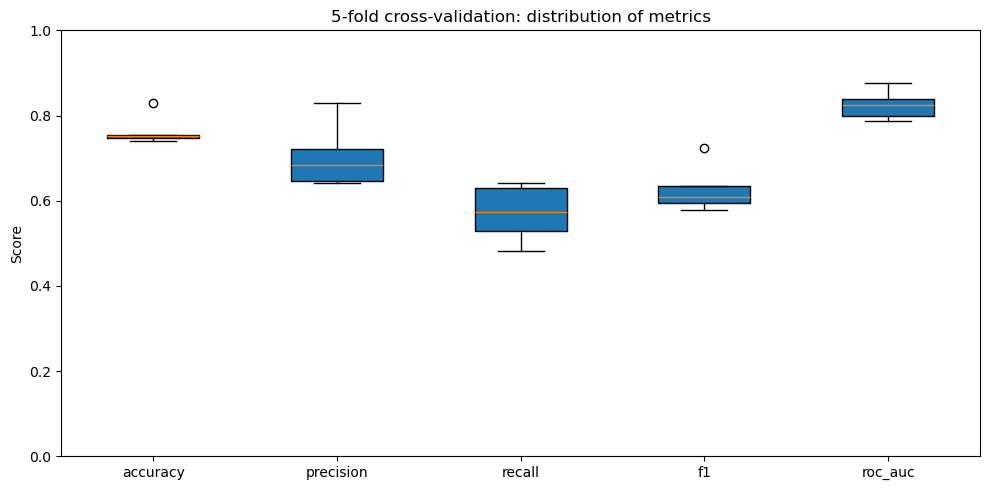


Conclusion:

• Gjennomsnittlig accuracy: 76.4%
• Standardavvik: 3.3%

Tolkning:
• Low standard deviation (< 5%) indicates a stable model
• High standard deviation means performance varies substantially across folds
• Cross-validation provides a more reliable estimate than a single train/test split

Recall (57.1%) er lavere enn precision (70.4%)
→ Modellen er konservativ: Den overser noen diabetikere
→ For screening we should prioritize higher recall!



In [22]:
# ============================================================================
# TASK 4: CROSS-VALIDATION
# ============================================================================

print("="*70)
print("TASK 4: 5-fold cross-validation")
print("="*70)

rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Different metrics
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("\n5-fold CV results:")
print("-" * 60)

cv_results = {}
for metric in metrics:
    scores = cross_val_score(rf, X, y, cv=5, scoring=metric)
    cv_results[metric] = scores
    print(f"   {metric:<12}: {scores.mean():.3f} ± {scores.std():.3f}  (min: {scores.min():.3f}, max: {scores.max():.3f})")

# Visualiser
fig, ax = plt.subplots(figsize=(10, 5))
positions = range(len(metrics))
bp = ax.boxplot([cv_results[m] for m in metrics], positions=positions, patch_artist=True)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('5-fold cross-validation: distribution of metrics')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Conclusion:")
print("="*70)
print(f"""
• Gjennomsnittlig accuracy: {cv_results['accuracy'].mean():.1%}
• Standardavvik: {cv_results['accuracy'].std():.1%}

Tolkning:
• Low standard deviation (< 5%) indicates a stable model
• High standard deviation means performance varies substantially across folds
• Cross-validation provides a more reliable estimate than a single train/test split

Recall ({cv_results['recall'].mean():.1%}) er lavere enn precision ({cv_results['precision'].mean():.1%})
→ Modellen er konservativ: Den overser noen diabetikere
→ For screening we should prioritize higher recall!
""")

---

## Task 5: ROC curve and AUC

**Task:** Plot an ROC curve and compute AUC.

### Solution:

TASK 5: ROC curve and AUC


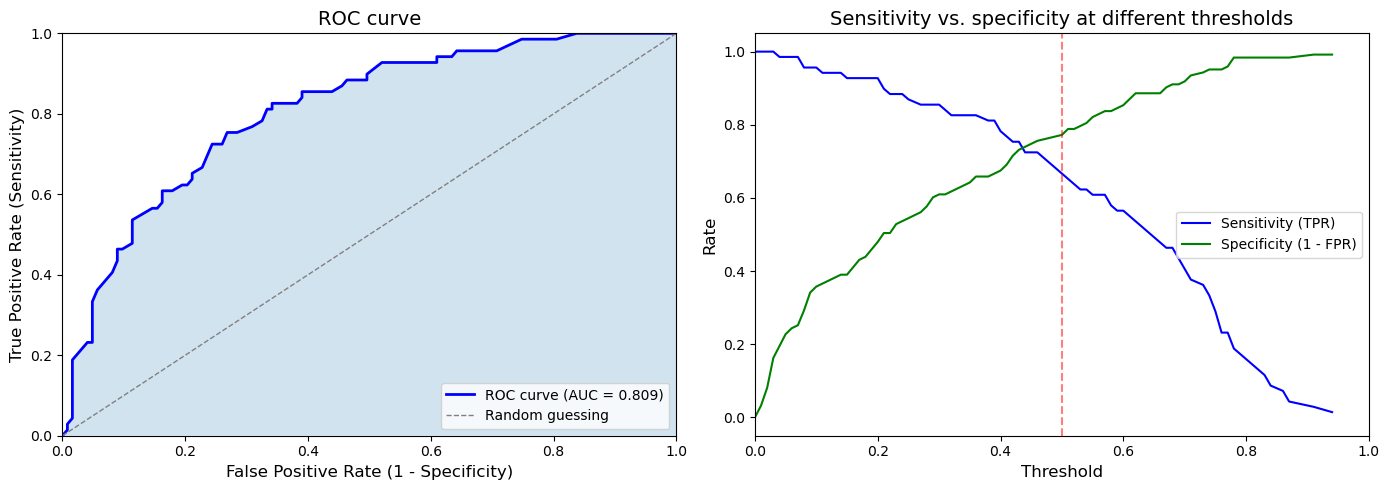


Results:
─────────────────────────────────────────────────────────────
  AUC (Area Under Curve): 0.809

  Optimal threshold (Youden's J): 0.43
    → Sensitivity: 75.4%
    → Specificity: 73.2%


Conclusion:

Interpreting AUC = 0.809:
• 0.5 = random guessing (useless model)
• 0.7–0.8 = acceptable discrimination
• 0.8–0.9 = good discrimination
• > 0.9 = excellent discrimination

Our model (0.809) has good ability to
separate people with diabetes from those without diabetes.

The ROC curve shows the trade-off between sensitivity and specificity.
Lowering the threshold increases sensitivity, but decreases specificity.



In [23]:
# ============================================================================
# TASK 5: ROC CURVE AND AUC
# ============================================================================

print("="*70)
print("TASK 5: ROC curve and AUC")
print("="*70)

# Train model and get probabilities
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_proba = rf.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ROC curve
ax1 = axes[0]
ax1.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guessing')
ax1.fill_between(fpr, tpr, alpha=0.2)
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax1.set_title('ROC curve', fontsize=14)
ax1.legend(loc='lower right')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Right: threshold vs. metrics
# Note: roc_curve returns arrays of the same length; plot all values
ax2 = axes[1]
ax2.plot(thresholds, tpr, label='Sensitivity (TPR)', color='blue')
ax2.plot(thresholds, 1 - fpr, label='Specificity (1 - FPR)', color='green')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Rate', fontsize=12)
ax2.set_title('Sensitivity vs. specificity at different thresholds', fontsize=14)
ax2.legend()
ax2.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Default threshold')
ax2.set_xlim([0, 1])  # Limit x-axis to relevant thresholds

plt.tight_layout()
plt.show()

# Find optimal threshold (Youden's J)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"""
Results:
─────────────────────────────────────────────────────────────
  AUC (Area Under Curve): {roc_auc:.3f}

  Optimal threshold (Youden's J): {optimal_threshold:.2f}
    → Sensitivity: {tpr[optimal_idx]:.1%}
    → Specificity: {1 - fpr[optimal_idx]:.1%}
""")

print("\n" + "="*70)
print("Conclusion:")
print("="*70)
print(f"""
Interpreting AUC = {roc_auc:.3f}:
• 0.5 = random guessing (useless model)
• 0.7–0.8 = acceptable discrimination
• 0.8–0.9 = good discrimination
• > 0.9 = excellent discrimination

Our model ({roc_auc:.3f}) has {'good' if roc_auc > 0.8 else 'acceptable'} ability to
separate people with diabetes from those without diabetes.

The ROC curve shows the trade-off between sensitivity and specificity.
Lowering the threshold increases sensitivity, but decreases specificity.
""")

---

# 📊 ANALYTICAL TASKS (6–8)

---

## Task 6: Optimal decision threshold

**Task:** Analyze precision, recall and F1 at different thresholds.

### Solution:

TASK 6: Analysis of different thresholds

Metrikker ved ulike terskelverdier:
--------------------------------------------------------------------------------
Threshold  Precision    Recall       F1           Accuracy    
--------------------------------------------------------------------------------
0.2        50.0%        92.8%        65.0%        64.1%       
0.3        55.1%        85.5%        67.0%        69.8%       
0.4        57.4%        78.3%        66.3%        71.4%       
0.5        62.2%        66.7%        64.3%        73.4%       
0.6        68.4%        56.5%        61.9%        75.0%       
0.7        73.7%        40.6%        52.3%        73.4%       
0.8        84.6%        15.9%        26.8%        68.8%       


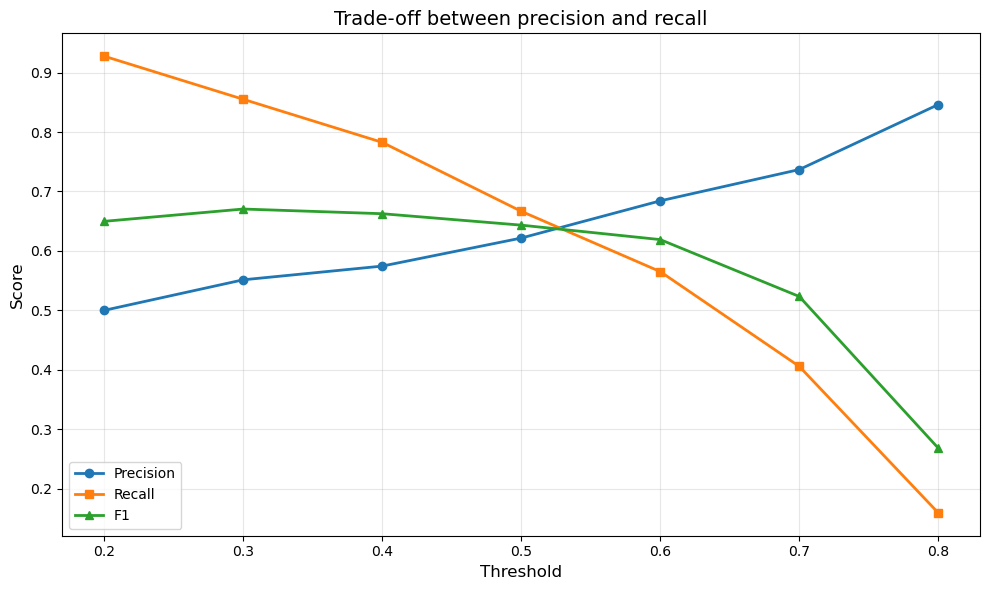


Conclusion and recommendations:

FOR SCREENING (we want to catch ALL sick patients):
• Recommended threshold: 0.3 or lower
• High recall (catches most people with diabetes)
• Accept more false positives (extra testing)
• Example: annual health checks in high-risk groups

FOR CONFIRMATORY TESTING (we want to be SURE):
• Recommended threshold: 0.6 or higher
• High precision (those we label sick are actually sick)
• Risk missing some sick patients
• Example: before starting medication

FOR BALANCED USE:
• Threshold: 0.4–0.5 (maximizes F1)
• Compromise between precision and recall



In [24]:
# ============================================================================
# TASK 6: OPTIMAL DECISION THRESHOLD
# ============================================================================

print("="*70)
print("TASK 6: Analysis of different thresholds")
print("="*70)

# Get probabilities
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_proba = rf.predict_proba(X_test)[:, 1]

# Test ulike terskler
thresholds_to_test = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print("\nMetrikker ved ulike terskelverdier:")
print("-" * 80)
print(f"{'Threshold':<10} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy':<12}")
print("-" * 80)

results = []
for thresh in thresholds_to_test:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    acc = accuracy_score(y_test, y_pred_thresh)
    
    results.append({'Threshold': thresh, 'Precision': prec, 'Recall': rec, 'F1': f1, 'Accuracy': acc})
    print(f"{thresh:<10} {prec:<12.1%} {rec:<12.1%} {f1:<12.1%} {acc:<12.1%}")

# Visualiser
results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_df['Threshold'], results_df['Precision'], 'o-', label='Precision', linewidth=2)
ax.plot(results_df['Threshold'], results_df['Recall'], 's-', label='Recall', linewidth=2)
ax.plot(results_df['Threshold'], results_df['F1'], '^-', label='F1', linewidth=2)
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Trade-off between precision and recall', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Conclusion and recommendations:")
print("="*70)
print("""
FOR SCREENING (we want to catch ALL sick patients):
• Recommended threshold: 0.3 or lower
• High recall (catches most people with diabetes)
• Accept more false positives (extra testing)
• Example: annual health checks in high-risk groups

FOR CONFIRMATORY TESTING (we want to be SURE):
• Recommended threshold: 0.6 or higher
• High precision (those we label sick are actually sick)
• Risk missing some sick patients
• Example: before starting medication

FOR BALANCED USE:
• Threshold: 0.4–0.5 (maximizes F1)
• Compromise between precision and recall
""")

---

## Task 7: Confusion-matrix analysis

**Task:** Analyze the confusion matrix and the consequences of errors.

### Solution:

TASK 7: Confusion matrix and consequences of errors


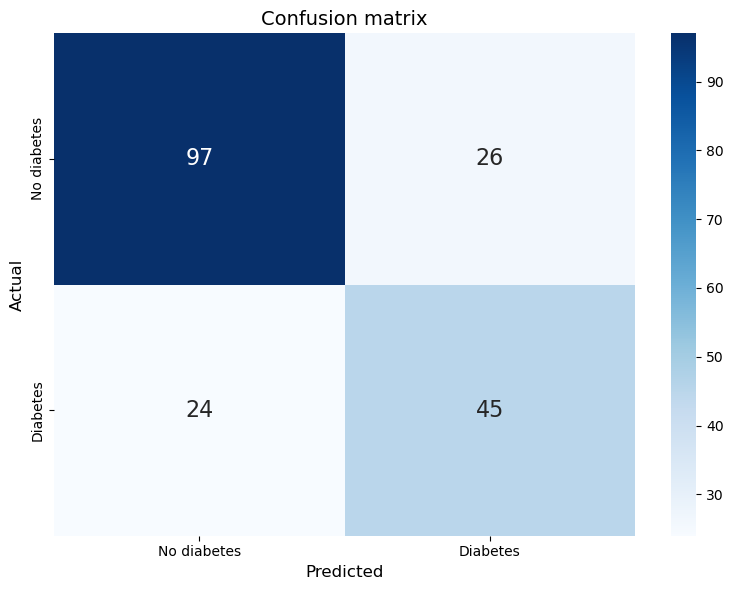


Confusion-matrix values:
─────────────────────────────────────────────────────────────
  True Negatives (TN):   97  - Healthy, correctly identified
  False Positives (FP):  26  - Healthy, incorrectly labeled as diabetes
  False Negatives (FN):  24  - Sick, missed by the model
  True Positives (TP):   45  - Sick, correctly identified


Consequence analysis:

FALSE POSITIVES (26 cases):
─────────────────────────────────────────────────────────────
• Consequence: Unnecessary worry and testing
• Cost: HbA1c test (~200 NOK), doctor visit, psychological burden
• Severity: MODERATE — unpleasant, but not dangerous

FALSE NEGATIVES (24 cases):
─────────────────────────────────────────────────────────────
• Consequence: Delayed diagnosis and treatment
• Cost: Increased risk of complications (kidney failure, blindness, amputation)
• Severity: HIGH — can be life-threatening

CONCLUSION:
─────────────────────────────────────────────────────────────
In a medical context, FALSE NEGATIVES are typical

In [26]:
# ============================================================================
# TASK 7: CONFUSION-MATRIX ANALYSIS
# ============================================================================

print("="*70)
print("TASK 7: Confusion matrix and consequences of errors")
print("="*70)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
xticklabels=['No diabetes', 'Diabetes'],
               yticklabels=['No diabetes', 'Diabetes'],  ax=ax,
            annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion matrix', fontsize=14)
plt.tight_layout()
plt.show()

print(f"""
Confusion-matrix values:
─────────────────────────────────────────────────────────────
  True Negatives (TN):  {tn:>3}  - Healthy, correctly identified
  False Positives (FP): {fp:>3}  - Healthy, incorrectly labeled as diabetes
  False Negatives (FN): {fn:>3}  - Sick, missed by the model
  True Positives (TP):  {tp:>3}  - Sick, correctly identified
""")

print("\n" + "="*70)
print("Consequence analysis:")
print("="*70)
print(f"""
FALSE POSITIVES ({fp} cases):
─────────────────────────────────────────────────────────────
• Consequence: Unnecessary worry and testing
• Cost: HbA1c test (~200 NOK), doctor visit, psychological burden
• Severity: MODERATE — unpleasant, but not dangerous

FALSE NEGATIVES ({fn} cases):
─────────────────────────────────────────────────────────────
• Consequence: Delayed diagnosis and treatment
• Cost: Increased risk of complications (kidney failure, blindness, amputation)
• Severity: HIGH — can be life-threatening

CONCLUSION:
─────────────────────────────────────────────────────────────
In a medical context, FALSE NEGATIVES are typically worse than FALSE POSITIVES.
It is better to give some healthy people an extra test (FP) than to miss
sick patients (FN).

→ We should consider lowering the threshold to reduce FN, even if it increases FP.
""")

---

## Task 8: Subgroup analysis

**Task:** Analyze the model’s performance across different age groups.

### Solution:

TASK 8: Subgroup analysis (age groups)

Performance by age group:
----------------------------------------------------------------------
Age group       N        Accuracy     Recall       Diabetes %  
----------------------------------------------------------------------
Under 30        97       79.4%        39.1%        23.7%       
30–50           66       69.7%        73.0%        56.1%       
Over 50         29       65.5%        100.0%       31.0%       


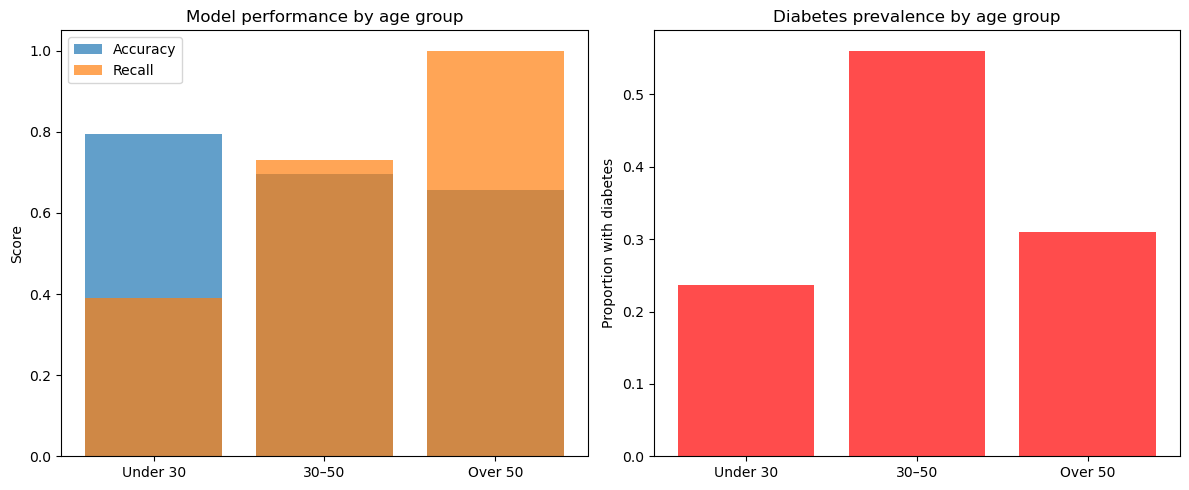


Conclusion:

Observations:
• Diabetes prevalence increases strongly with age (as expected)
• The model may have different performance across age groups
• Recall is especially important to monitor — do we catch sick patients in all groups?

Fairness implications:
• If the model performs worse for younger people, it may miss diabetes in that group
• Different groups may require different thresholds
• Subgroup analysis is essential before clinical deployment!

Recommendations:
• Always report performance per subgroup (age, sex, ethnicity)
• Consider separate models or adjusted thresholds for different groups
• Pay special attention to groups with few observations



In [30]:
# ============================================================================
# TASK 8: SUBGROUP ANALYSIS
# ============================================================================

print("="*70)
print("TASK 8: Subgroup analysis (age groups)")
print("="*70)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Define age groups
age_groups = [
    ('Under 30', X_test['age'] < 30),
    ('30–50', (X_test['age'] >= 30) & (X_test['age'] < 50)),
    ('Over 50', X_test['age'] >= 50)
]

print("\nPerformance by age group:")
print("-" * 70)
print(f"{'Age group':<15} {'N':<8} {'Accuracy':<12} {'Recall':<12} {'Diabetes %':<12}")
print("-" * 70)

results = []
for name, mask in age_groups:
    if mask.sum() > 0:
        y_true_sub = y_test[mask]
        y_pred_sub = rf.predict(X_test[mask])
        
        n = len(y_true_sub)
        acc = accuracy_score(y_true_sub, y_pred_sub)
        rec = recall_score(y_true_sub, y_pred_sub) if y_true_sub.sum() > 0 else 0
        diabetes_pct = y_true_sub.mean()
        
        results.append({'Group': name, 'N': n, 'Accuracy': acc, 'Recall': rec, 'Diabetes_pct': diabetes_pct})
        print(f"{name:<15} {n:<8} {acc:<12.1%} {rec:<12.1%} {diabetes_pct:<12.1%}")

# Visualize
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
x = range(len(results_df))
ax1.bar(x, results_df['Accuracy'], alpha=0.7, label='Accuracy')
ax1.bar(x, results_df['Recall'], alpha=0.7, label='Recall')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Group'])
ax1.set_ylabel('Score')
ax1.set_title('Model performance by age group')
ax1.legend()

ax2 = axes[1]
ax2.bar(x, results_df['Diabetes_pct'], color='red', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Group'])
ax2.set_ylabel('Proportion with diabetes')
ax2.set_title('Diabetes prevalence by age group')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Conclusion:")
print("="*70)
print("""
Observations:
• Diabetes prevalence increases strongly with age (as expected)
• The model may have different performance across age groups
• Recall is especially important to monitor — do we catch sick patients in all groups?

Fairness implications:
• If the model performs worse for younger people, it may miss diabetes in that group
• Different groups may require different thresholds
• Subgroup analysis is essential before clinical deployment!

Recommendations:
• Always report performance per subgroup (age, sex, ethnicity)
• Consider separate models or adjusted thresholds for different groups
• Pay special attention to groups with few observations
""")

---

# 🤔 ETHICAL DISCUSSIONS (9–12)

---

## Task 9: Population bias

**Task:** Can the model be used for Norwegian patients?

### Discussion

**Question:** The dataset is from Pima women in Arizona. Can the model be generalized to other populations, e.g., Norwegian patients?

#### Factors that can vary across populations

| Factor | Pima population | Norwegian patients |
|--------|------------------|-------------------|
| **Genetics** | High genetic predisposition for diabetes | Mixed genetic background |
| **Diet** | Traditional vs. Western diet | Nordic diet |
| **Obesity prevalence** | Historically high | Moderate, increasing |
| **Physical activity** | Varies | Generally higher |
| **Healthcare access** | Variable access | Good access |
| **BMI cutoffs** | Standard | May vary across ethnicities |

#### Arguments AGAINST direct use

1. **Biological differences:** The Pima population has a unique genetic predisposition
2. **Environmental factors:** Different diet and lifestyle patterns
3. **Historical context:** Data from 1988 — much has changed
4. **Lack of validation:** The model has not been tested on Norwegian data

#### What would be required for use in Norway?

1. **Retrospective validation:** Test the model on Norwegian patient data
2. **Prospective study:** Follow patients over time to measure real-world performance
3. **Recalibration:** Adjust model parameters for the Norwegian population
4. **Retraining:** Train the model from scratch on Norwegian data
5. **Regulatory approval:** CE marking as a medical device

#### Conclusion

> **The model should NOT be used directly on Norwegian patients without extensive validation and recalibration.**
> The principles and methodology transfer, but the model itself must be adapted to local conditions.

---

## Task 10: Historical bias

**Task:** The data are from 1988. Are they still relevant?

### Discussion

**Changes since 1988:**

| Aspect | 1988 | 2024 |
|--------|------|------|
| **Diagnostic criteria** | Fasting glucose ≥ 140 mg/dL | Fasting glucose ≥ 126 mg/dL |
| **HbA1c** | Not used for diagnosis | HbA1c ≥ 6.5% is diagnostic |
| **Obesity prevalence** | Lower | Much higher (epidemic) |
| **Population age distribution** | Younger | Older (more diabetes) |
| **Treatment regimens** | Limited | Many new medications |
| **Measurement equipment** | Less precise | More precise |

#### Consequences of outdated data

1. **Changed thresholds:** The model may misclassify patients near cutoff values
2. **Population shifts:** Today’s patients may have a different risk profile
3. **Missing variables:** New risk factors have been identified (e.g., sleep apnea)
4. **Technology changes:** Measurement methods can produce systematically different values

#### What is still relevant?

- **Basic physiology:** Glucose and insulin work the same
- **Risk factors:** BMI, age, genetics are still important
- **Methodology:** The machine-learning approach is still valid

#### Conclusion

> **The data are valuable for teaching and method development, but should not be used for clinical decisions in 2024.**
> An updated model would need data from the last 5–10 years using modern diagnostic criteria.

---

## Task 11: Sex and diversity perspective

**Task:** The dataset contains only women. Can the model be used for men?

### Discussion

**Biological sex differences in diabetes:**

| Factor | Women | Men |
|--------|-------|-----|
| **Body fat distribution** | Subcutaneous (under the skin) | Visceral (around organs) |
| **Insulin sensitivity** | Generally higher | Generally lower |
| **Hormones** | Estrogen is protective (pre-menopause) | Testosterone influences risk |
| **Gestational diabetes** | Relevant risk factor | Not applicable |
| **Symptoms** | Can be atypical | Often “classic” symptoms |
| **Complications** | Higher risk of heart disease | Higher risk of kidney disease |

#### Problems with using the model for men

1. **Pregnancies:** The variable `pregnancies` is meaningless for men
2. **BMI interpretation:** The same BMI can imply different risk in men vs women
3. **Validation:** The model has never been tested on men
4. **Systematic bias:** Predictions may be systematically wrong

#### A fair medical AI system should

1. **Include both sexes** in the training data
2. **Report performance separately** for men and women
3. **Consider sex-specific models** if performance differs substantially
4. **State limitations clearly** in the documentation

#### Conclusion

> **The model should NOT be used for men.**
> One variable (`pregnancies`) is not applicable, and biological differences make it likely that the model will produce unreliable predictions.
> A fair system would require sex-balanced data and separate validation.

---

## Task 12: Informed consent

**Task:** Should the patient know that AI is involved?

### Discussion

**Arguments FOR informing the patient:**

1. **Autonomy:** The patient has a right to know how decisions about their health are made
2. **Trust:** Transparency builds trust in healthcare
3. **Legal requirements:** GDPR Article 22 supports a right to information/explanation for automated decisions
4. **Ethical guidelines:** Most ethical frameworks require transparency

**Arguments AGAINST full transparency:**

1. **Complexity:** ML models can be hard to explain to non-experts
2. **Unnecessary worry:** Some patients may become anxious about “robot diagnostics”
3. **Practical feasibility:** Explaining it in every consultation can be time-consuming

#### How to explain the model’s decision

**Bad explanation:**
> "The computer says you have a 73% chance of diabetes." 

**Good explanation:**
> "Based on your lab results and health data, we used an analysis tool that helps us assess risk. Your values — especially glucose and BMI — indicate elevated risk. We recommend further tests to confirm or rule this out." 

#### What if the patient refuses an AI-based assessment?

The patient should have the right to:
1. Request an assessment based only on the clinician’s judgment
2. See how the AI tool influenced the recommendation
3. File a complaint if they believe the AI use was inappropriate

#### Conclusion

> **Yes, the patient should be informed that AI is used as decision support.**
> The information should be adapted to the patient’s level of understanding, focus on what it means for them, and clarify that the clinician has the final responsibility.

---

# 🏥 CLINICAL PERSPECTIVES (13–15)

---

## Task 13: Integration into clinical practice

**Task:** How can diabetes prediction be integrated into a clinician’s workflow?

### Discussion

#### Suggested integration

```
┌─────────────────────────────────────────────────────────────────────┐
│               CLINICAL WORKFLOW WITH AI SUPPORT                     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. PATIENT ARRIVES                                                 │
│     ↓                                                               │
│  2. NURSE TAKES MEASUREMENTS                                        │
│     • Blood pressure, weight, height → BMI                          │
│     • Blood tests: Glucose, HbA1c                                   │
│     ↓                                                               │
│  3. DATA ARE ENTERED INTO THE EHR                                   │
│     ↓                                                               │
│  4. AI MODEL RUNS AUTOMATICALLY (background)                        │
│     ↓                                                               │
│  5. CLINICIAN VIEWS CHART WITH AI FLAG                              │
│     ┌───────────────────────────────────────┐                       │
│     │ ⚠️ ELEVATED DIABETES RISK (73%)       │                       │
│     │ Main factors: Glucose ↑, BMI ↑        │                       │
│     │ [Details] [Dismiss] [Confirm]         │                       │
│     └───────────────────────────────────────┘                       │
│     ↓                                                               │
│  6. CLINICIAN MAKES A CLINICAL DECISION                             │
│     • Considers AI suggestion + own observations                    │
│     • Documents rationale in the chart                              │
│     ↓                                                               │
│  7. FOLLOW-UP IS PLANNED                                            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

#### Required guardrails

| Guardrail | Description |
|-----------|-------------|
| **Confidence threshold** | Flag only predictions with > 60% confidence |
| **Logging** | Log all AI predictions and clinician decisions |
| **Override capability** | The clinician can always override the AI |
| **Regular audit** | Monthly review of AI performance |
| **Fallback** | System works without AI if there is a technical failure |
| **Patient information** | Automatic note about AI use in the chart |

#### When the clinician disagrees with the model

1. **Document the disagreement** in the patient chart
2. **Justify the deviation** (which clinical information did the AI not have access to?)
3. **Follow up the patient** to see which assessment was correct
4. **Report to the AI team** for potential model improvement

#### Conclusion

> **AI should be a support tool, not a decision-maker.**
> The system must be designed so clinicians can easily see, understand, and override AI recommendations.

---

## Task 14: Cost–benefit analysis

**Task:** Analyze the economic aspects of the model’s errors.

TASK 14: Cost–benefit analysis

Analyse ved ulike terskler:
----------------------------------------------------------------------
Threshold  FP     FN     Cost FP      Cost FN      Total       
----------------------------------------------------------------------
0.2        64     5          32,000 kr    250,000 kr    294,800 kr
0.3        48     10         24,000 kr    500,000 kr    535,800 kr
0.4        40     15         20,000 kr    750,000 kr    780,800 kr
0.5        28     23         14,000 kr  1,150,000 kr  1,173,200 kr
0.6        18     30          9,000 kr  1,500,000 kr  1,516,800 kr
0.7        10     41          5,000 kr  2,050,000 kr  2,060,600 kr


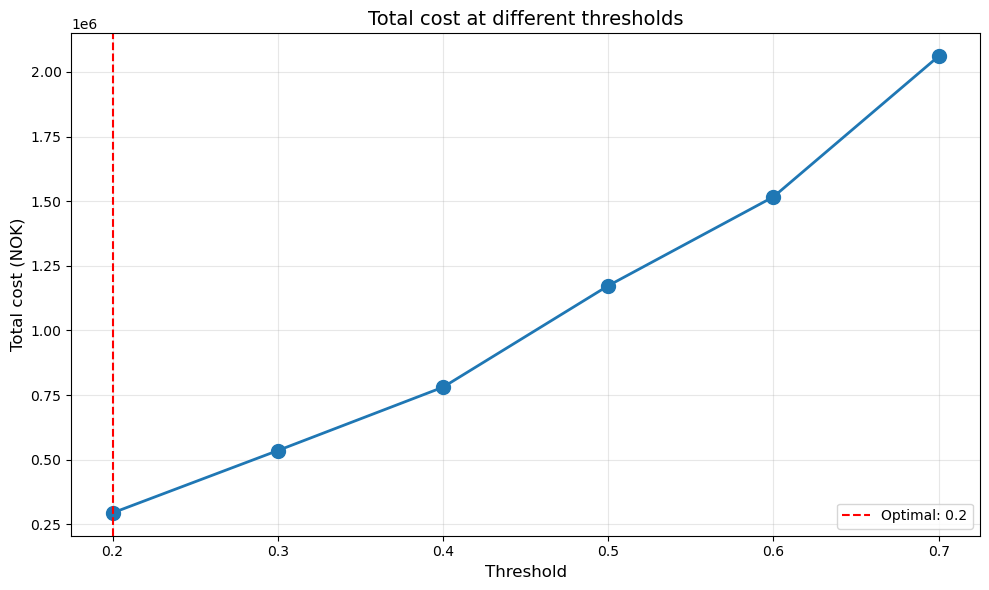


Optimal threshold based on cost: 0.2
Total cost at the optimal threshold: 294,800.0 NOK

NOTE: These numbers are illustrative. In reality, costs are
much more complex to estimate, and include:
• Direct medical costs
• Indirect costs (sick leave, lost productivity)
• Quality of life (QALY)
• Psychological burden


Ethical reflection:

Is it ethically acceptable to base medical decisions on economics?

Arguments YES:
• Resources are limited — we have to prioritize
• Cost-effectiveness frees resources for other patients
• Society already uses QALY in prioritization decisions

Arguments NO:
• Health should not be given a price tag
• Can lead to discrimination against "expensive" patient groups
• Economic models can overlook important human factors

Balanced view:
Economics should be ONE factor in decisions, but never the only one.
Clinical judgment, patient preferences, and ethical principles must carry weight.



In [32]:
# ============================================================================
# TASK 14: COST–BENEFIT ANALYSIS
# ============================================================================

print("="*70)
print("TASK 14: Cost–benefit analysis")
print("="*70)

# Define costs (example values in NOK)
cost_fp = 500     # False positive: extra HbA1c test + doctor visit
cost_fn = 50000   # False negative: delayed diagnosis → complications
cost_tp = 200     # True positive: test confirms, treatment starts
cost_tn = 0       # True negative: no additional cost

# Get confusion matrix
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("\nAnalyse ved ulike terskler:")
print("-" * 70)
print(f"{'Threshold':<10} {'FP':<6} {'FN':<6} {'Cost FP':<12} {'Cost FN':<12} {'Total':<12}")
print("-" * 70)

y_proba = rf.predict_proba(X_test)[:, 1]
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = []
for thresh in thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    total_cost = fp * cost_fp + fn * cost_fn + tp * cost_tp + tn * cost_tn
    results.append({'Threshold': thresh, 'FP': fp, 'FN': fn, 'Cost': total_cost})
    
    print(f"{thresh:<10} {fp:<6} {fn:<6} {fp*cost_fp:>10,} kr {fn*cost_fn:>10,} kr {total_cost:>10,} kr")

# Find optimal threshold
results_df = pd.DataFrame(results)
optimal = results_df.loc[results_df['Cost'].idxmin()]

# Visualiser
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results_df['Threshold'], results_df['Cost'], 'o-', linewidth=2, markersize=10)
ax.axvline(x=optimal['Threshold'], color='red', linestyle='--', label=f"Optimal: {optimal['Threshold']}")
ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Total cost (NOK)', fontsize=12)
ax.set_title('Total cost at different thresholds', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"""
Optimal threshold based on cost: {optimal['Threshold']}
Total cost at the optimal threshold: {optimal['Cost']:,} NOK

NOTE: These numbers are illustrative. In reality, costs are
much more complex to estimate, and include:
• Direct medical costs
• Indirect costs (sick leave, lost productivity)
• Quality of life (QALY)
• Psychological burden
""")

print("\n" + "="*70)
print("Ethical reflection:")
print("="*70)
print("""
Is it ethically acceptable to base medical decisions on economics?

Arguments YES:
• Resources are limited — we have to prioritize
• Cost-effectiveness frees resources for other patients
• Society already uses QALY in prioritization decisions

Arguments NO:
• Health should not be given a price tag
• Can lead to discrimination against "expensive" patient groups
• Economic models can overlook important human factors

Balanced view:
Economics should be ONE factor in decisions, but never the only one.
Clinical judgment, patient preferences, and ethical principles must carry weight.
""")

---

## Task 15: The future of diabetes prediction

**Task:** Design an optimal diabetes prediction system.

### Discussion

#### 1. Additional variables to include

| Category | Variables | Rationale |
|----------|-----------|-----------|
| **Genetics** | Polygenic risk score, family history | Inherited predisposition |
| **Lifestyle** | Diet, physical activity, sleep | Modifiable risk factors |
| **Biomarkers** | HbA1c, triglycerides, HDL | More accurate measurement |
| **Continuous data** | CGM (continuous glucose monitoring) | Dynamic risk |
| **Socioeconomic** | Education, income, residence | Influences health behavior |
| **Mental health** | Stress, depression | Correlates with diabetes |
| **Medications** | Steroids, antipsychotics | Can increase diabetes risk |

#### 2. Ensuring fairness for all patient groups

```
┌─────────────────────────────────────────────────────────────────────┐
│                   STRATEGY FOR FAIR AI                              │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. REPRESENTATIVE DATA                                             │
│     • Balanced by sex, age, ethnicity                               │
│     • Actively include underrepresented groups                      │
│                                                                     │
│  2. SUBGROUP VALIDATION                                             │
│     • Test performance separately for each group                    │
│     • Define acceptable differences in advance                      │
│                                                                     │
│  3. BIAS AUDIT                                                      │
│     • Regular review of predictions                                 │
│     • Compare outcomes across groups                                │
│                                                                     │
│  4. INCLUSIVE DEVELOPMENT                                           │
│     • Involve patients and patient organizations                    │
│     • Include clinicians from diverse settings                      │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

#### 3. Required regulations and approvals

| Step | Description | Timeline |
|------|-------------|----------|
| **CE marking** | Classification as a medical device (MDR) | 1–2 years |
| **Clinical studies** | Prospective validation | 2–3 years |
| **Privacy impact assessment (DPIA)** | GDPR compliance | 3–6 months |
| **Ethics approval** | REK/NEM (or equivalent) | 3–6 months |
| **Hospital/health-system approval** | Local implementation | 6–12 months |

#### 4. Measuring success after implementation

**Clinical metrics:**
- Share of newly diagnosed diabetes detected earlier
- Reduction in complications (kidney disease, retinopathy)
- Time from prediction to treatment start

**Process metrics:**
- Share of clinicians who use the system
- Share of predictions the clinician agrees with
- Time spent per patient

**Patient metrics:**
- Patient satisfaction with AI-supported consultation
- Understanding of personal risk
- Adherence to recommendations

#### Conclusion:

> **An optimal diabetes prediction system requires:**
> - Rich, representative data
> - Continuous validation and improvement
> - Integration into existing clinical systems
> - Focus on fairness and transparency
> - A robust regulatory framework
> - Involvement of patients and clinicians

---

# 🏁 Conclusion

This notebook has given you:

✅ **Technical skills:** Model comparison, feature selection, cross-validation, ROC analysis

✅ **Analytical insight:** Threshold optimization, confusion-matrix interpretation, subgroup analysis

✅ **Ethical reflection:** Bias, fairness, informed consent, population generalization

✅ **Clinical perspective:** Workflow integration, cost–benefit, future development

---

> 🎯 **Key message:** Medical AI is about much more than maximizing accuracy.
> Context, ethics, fairness and clinical relevance are just as important as technical performance.